In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import LocalOutlierFactor
from scipy import linalg
import warnings
warnings.filterwarnings('ignore')

In [2]:
G = nx.Graph()

with open('ca-AstroPh.txt', 'r') as f:
    for line in f:
        nodes = line.strip().split()
        node1, node2 = int(nodes[0]), int(nodes[1])
        
        # Add edge or increment weight if edge exists
        if G.has_edge(node1, node2):
            G[node1][node2]['weight'] += 1
        else:
            G.add_edge(node1, node2, weight=1)

print(f"Graph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph loaded: 18772 nodes, 198110 edges


In [3]:
features = {}

for node in G.nodes():
    egonet = nx.ego_graph(G, node, radius=1)
    
    # Feature 1: Number of neighbors
    num_neighbors = len(list(G.neighbors(node)))
    
    # Feature 2: Number of edges in egonet
    num_edges = egonet.number_of_edges()
    
    # Feature 3: Total weight of egonet
    total_weight = egonet.size(weight='weight')
    
    # Feature 4: Principal eigenvalue of weighted adjacency matrix
    if len(egonet.nodes()) > 1:
        # Get weighted adjacency matrix
        adj_matrix = nx.adjacency_matrix(egonet, weight='weight').todense()
        # Compute eigenvalues
        eigenvalues = np.linalg.eigvalsh(adj_matrix)
        principal_eigenvalue = np.max(eigenvalues)
    else:
        principal_eigenvalue = 0
    
    # Store features
    features[node] = {
        'num_neighbors': num_neighbors,
        'num_edges': num_edges,
        'total_weight': total_weight,
        'principal_eigenvalue': principal_eigenvalue
    }

# Set node attributes in the graph
nx.set_node_attributes(G, features)

print(f"Features extracted for {len(features)} nodes")
print(f"Sample features for node {list(G.nodes())[0]}: {features[list(G.nodes())[0]]}")

Features extracted for 18772 nodes
Sample features for node 84424: {'num_neighbors': 75, 'num_edges': 286, 'total_weight': 571.0, 'principal_eigenvalue': np.float64(25.89489731949169)}


In [4]:
# num_edges vs num_neighbors in log scale
nodes_list = list(G.nodes())
X_log = []  # log(num_neighbors)
y_log = []  # log(num_edges)

for node in nodes_list:
    num_neighbors = features[node]['num_neighbors']
    num_edges = features[node]['num_edges']
    
    # Only include nodes with positive values
    if num_neighbors > 0 and num_edges > 0:
        X_log.append(np.log(num_neighbors))
        y_log.append(np.log(num_edges))

X_log = np.array(X_log).reshape(-1, 1)
y_log = np.array(y_log)

# log(y) = log(C) + θ*log(x)
model = LinearRegression()
model.fit(X_log, y_log)

print(f"Linear regression fitted: θ = {model.coef_[0]:.4f}, log(C) = {model.intercept_:.4f}")

# Compute anomaly scores for all nodes
anomaly_scores = {}

for node in nodes_list:
    num_neighbors = features[node]['num_neighbors']
    num_edges = features[node]['num_edges']
    
    if num_neighbors > 0 and num_edges > 0:
        # Predict log(num_edges) from log(num_neighbors)
        log_neighbors = np.log(num_neighbors)
        log_edges_pred = model.predict([[log_neighbors]])[0]
        
        # Convert back to original scale
        edges_pred = np.exp(log_edges_pred)
        
        # Compute anomaly score
        numerator = max(num_edges, edges_pred)
        denominator = min(num_edges, edges_pred)
        score = (numerator / denominator) * np.log(abs(num_edges - edges_pred) + 1)
        anomaly_scores[node] = score
    else:
        anomaly_scores[node] = 0

print(f"Anomaly scores computed for {len(anomaly_scores)} nodes")

Linear regression fitted: θ = 1.5981, log(C) = -0.0164
Anomaly scores computed for 18772 nodes


## Step 4: Visualize Top 10 Anomalous Nodes (First 1500 Edges)

Subset graph: 1103 nodes, 1458 edges

Top 10 anomalous nodes:
1. Node 85176: score = 34.6018
2. Node 13353: score = 34.2773
3. Node 1086: score = 32.4905
4. Node 93360: score = 31.9072
5. Node 110210: score = 30.5962
6. Node 34676: score = 29.0567
7. Node 69839: score = 27.9332
8. Node 9769: score = 27.2469
9. Node 100536: score = 26.3922
10. Node 15759: score = 26.2023


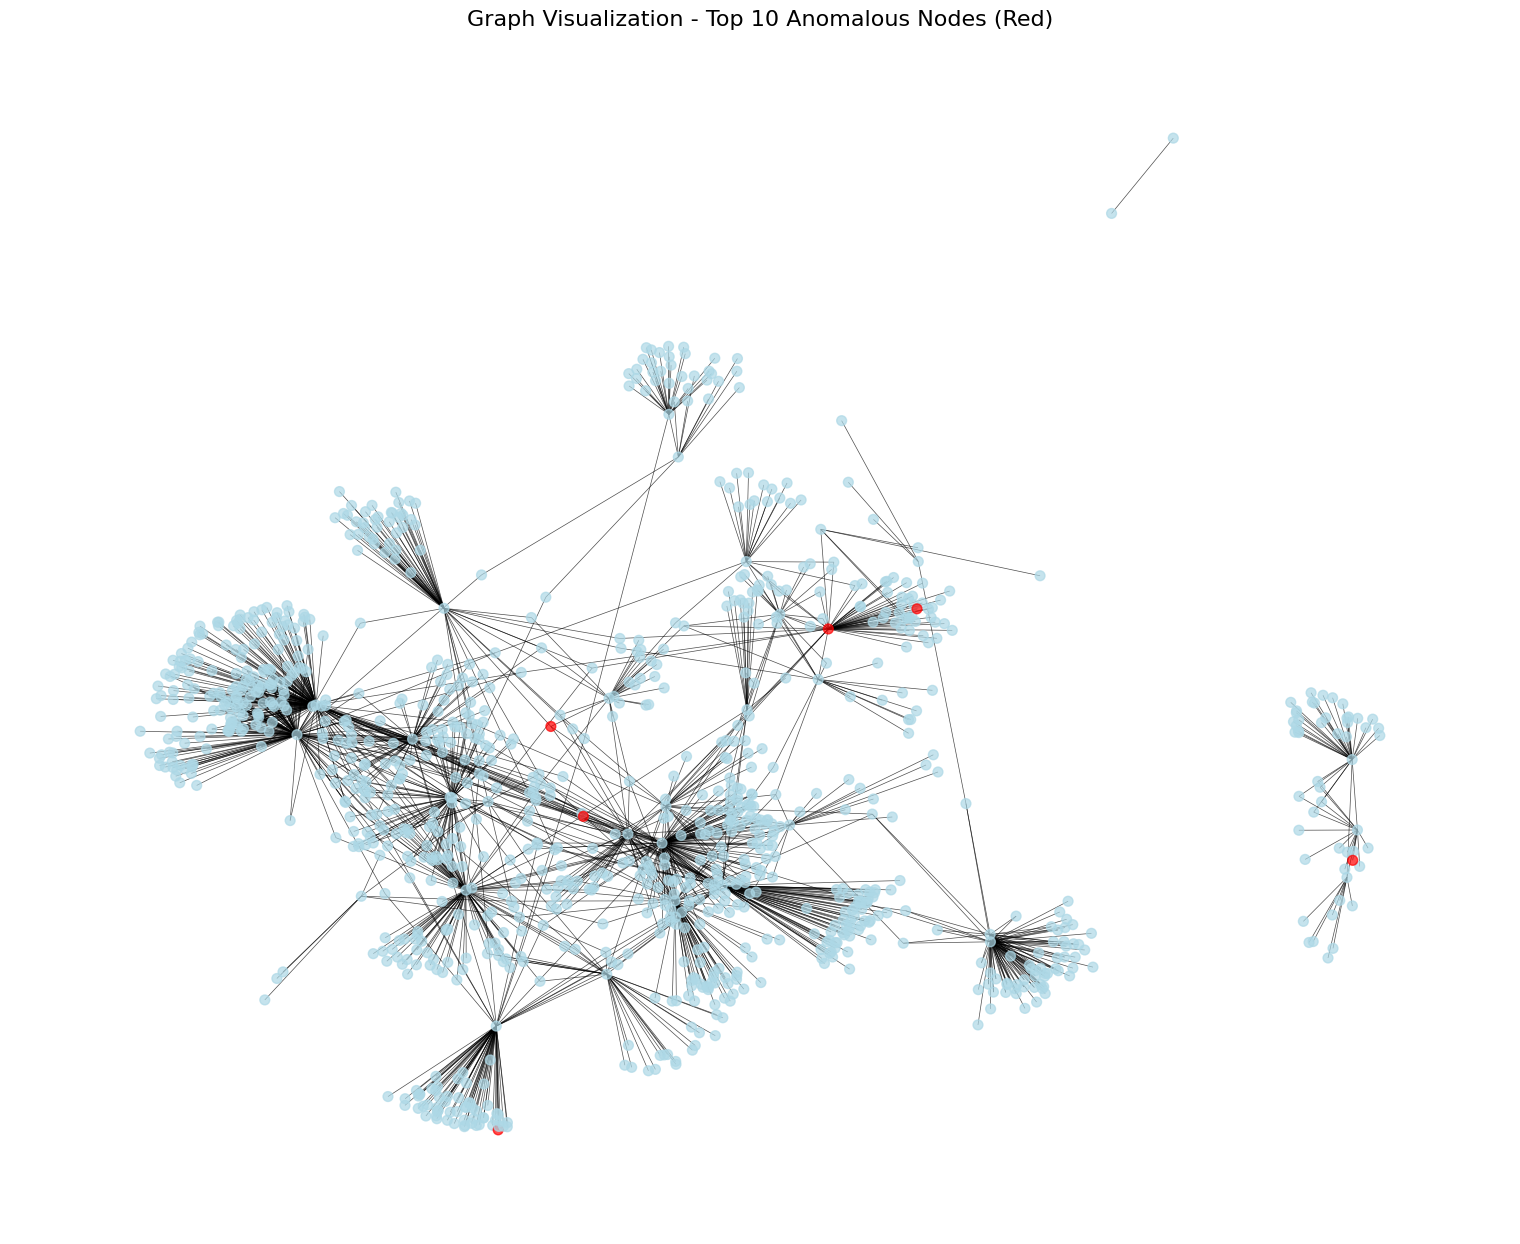

In [5]:
# subgraph with first 1500 edges
G_subset = nx.Graph()

with open('ca-AstroPh.txt', 'r') as f:
    for i, line in enumerate(f):
        if i >= 1500:
            break
        nodes = line.strip().split()
        node1, node2 = int(nodes[0]), int(nodes[1])
        
        if G_subset.has_edge(node1, node2):
            G_subset[node1][node2]['weight'] += 1
        else:
            G_subset.add_edge(node1, node2, weight=1)

print(f"Subset graph: {G_subset.number_of_nodes()} nodes, {G_subset.number_of_edges()} edges")

# Sort nodes by anomaly score
sorted_nodes = sorted(anomaly_scores.items(), key=lambda x: x[1], reverse=True)
top_10_anomalous = set([node for node, score in sorted_nodes[:10]])

print(f"\nTop 10 anomalous nodes:")
for i, (node, score) in enumerate(sorted_nodes[:10]):
    print(f"{i+1}. Node {node}: score = {score:.4f}")

# color map for visualization
node_colors = []
for node in G_subset.nodes():
    if node in top_10_anomalous:
        node_colors.append('red')
    else:
        node_colors.append('lightblue')

# Draw
plt.figure(figsize=(15, 12))
pos = nx.spring_layout(G_subset, k=0.5, iterations=50, seed=42)
nx.draw(G_subset, pos, node_color=node_colors, node_size=50, 
        width=0.5, alpha=0.7, with_labels=False)
plt.title('Graph Visualization - Top 10 Anomalous Nodes (Red)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
# LOF (num_edges and num_neighbors)
X_lof = []
node_order = []

for node in nodes_list:
    num_neighbors = features[node]['num_neighbors']
    num_edges = features[node]['num_edges']
    if num_neighbors > 0 and num_edges > 0:
        X_lof.append([num_edges, num_neighbors])
        node_order.append(node)

X_lof = np.array(X_lof)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
lof_scores = lof.fit_predict(X_lof)
lof_negative_outlier_factor = lof.negative_outlier_factor_

# Convert LOF scores (more negative is more anomalous)
# to positive anomaly scores
lof_anomaly_scores = -lof_negative_outlier_factor

print(f"LOF scores computed for {len(lof_anomaly_scores)} nodes")

# Normalize both scores to [0, 1] range
def normalize_scores(scores):
    scores_array = np.array(list(scores.values()))
    min_score = scores_array.min()
    max_score = scores_array.max()
    if max_score - min_score > 0:
        return {node: (score - min_score) / (max_score - min_score) 
                for node, score in scores.items()}
    else:
        return {node: 0 for node in scores.keys()}

normalized_lr_scores = normalize_scores(anomaly_scores)

# Create LOF score dictionary
lof_scores_dict = {}
for i, node in enumerate(node_order):
    lof_scores_dict[node] = lof_anomaly_scores[i]

normalized_lof_scores = normalize_scores(lof_scores_dict)

# Combine scores
combined_scores = {}
for node in nodes_list:
    lr_score = normalized_lr_scores.get(node, 0)
    lof_score = normalized_lof_scores.get(node, 0)
    combined_scores[node] = lr_score + lof_score

print("Combined scores computed (normalized LR + normalized LOF)")

LOF scores computed for 18772 nodes
Combined scores computed (normalized LR + normalized LOF)



Top 10 anomalous nodes (combined score):
1. Node 44255: combined score = 1.3976
2. Node 104312: combined score = 1.1680
3. Node 54558: combined score = 1.0596
4. Node 36617: combined score = 1.0158
5. Node 85176: combined score = 1.0000
6. Node 13353: combined score = 0.9906
7. Node 88583: combined score = 0.9769
8. Node 1086: combined score = 0.9390
9. Node 93360: combined score = 0.9221
10. Node 94797: combined score = 0.8911


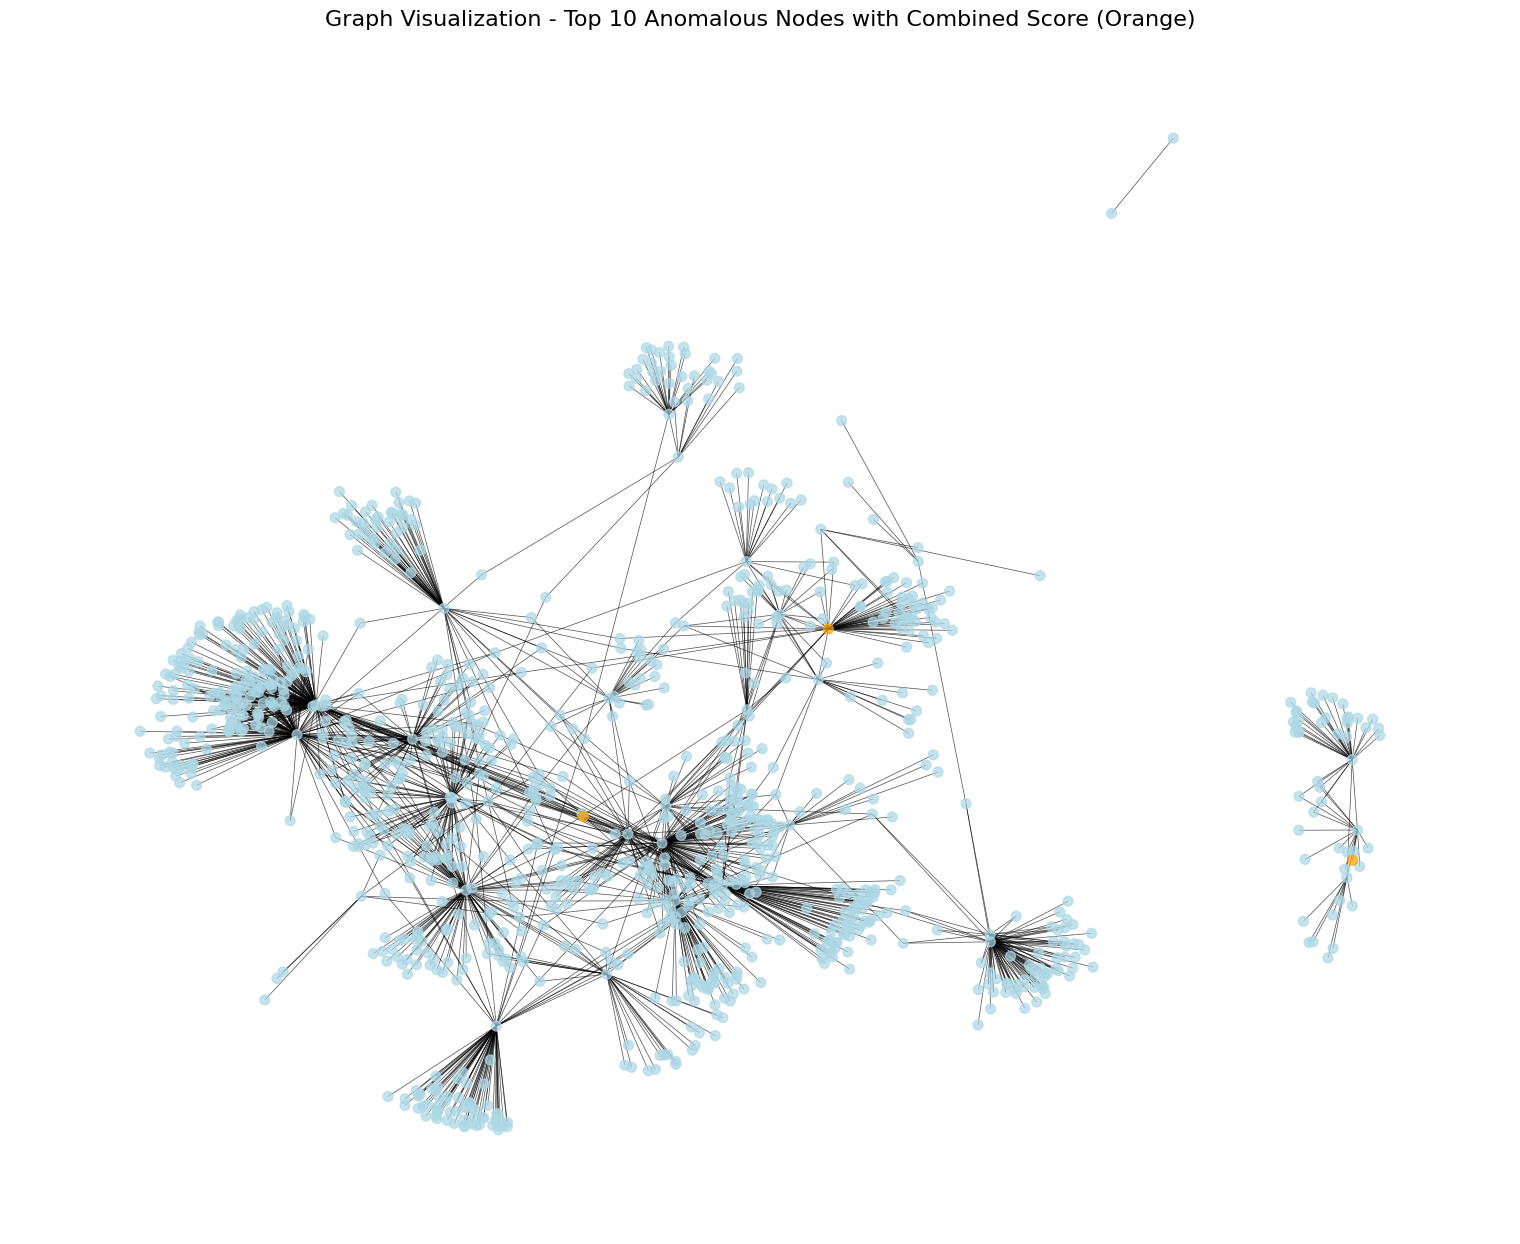

In [7]:
# Sort by combined scores
sorted_combined = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)
top_10_combined = set([node for node, score in sorted_combined[:10]])

print(f"\nTop 10 anomalous nodes (combined score):")
for i, (node, score) in enumerate(sorted_combined[:10]):
    print(f"{i+1}. Node {node}: combined score = {score:.4f}")

# Create color map for combined scores
node_colors_combined = []
for node in G_subset.nodes():
    if node in top_10_combined:
        node_colors_combined.append('orange')
    else:
        node_colors_combined.append('lightblue')

# Draw the graph with combined scores
plt.figure(figsize=(15, 12))
nx.draw(G_subset, pos, node_color=node_colors_combined, node_size=50, 
        width=0.5, alpha=0.7, with_labels=False)
plt.title('Graph Visualization - Top 10 Anomalous Nodes with Combined Score (Orange)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

## Comparison of Results

In [8]:
# Compare the two methods
print("Comparison of Top 10 Anomalous Nodes:\n")
print("Linear Regression Only:")
for i, (node, score) in enumerate(sorted_nodes[:10]):
    print(f"{i+1}. Node {node}: score = {score:.4f}")

print("\nCombined (LR + LOF):")
for i, (node, score) in enumerate(sorted_combined[:10]):
    print(f"{i+1}. Node {node}: score = {score:.4f}")

# Find overlap
overlap = top_10_anomalous.intersection(top_10_combined)
print(f"\nNodes appearing in both top 10 lists: {len(overlap)}")
print(f"Overlapping nodes: {sorted(list(overlap))}")

Comparison of Top 10 Anomalous Nodes:

Linear Regression Only:
1. Node 85176: score = 34.6018
2. Node 13353: score = 34.2773
3. Node 1086: score = 32.4905
4. Node 93360: score = 31.9072
5. Node 110210: score = 30.5962
6. Node 34676: score = 29.0567
7. Node 69839: score = 27.9332
8. Node 9769: score = 27.2469
9. Node 100536: score = 26.3922
10. Node 15759: score = 26.2023

Combined (LR + LOF):
1. Node 44255: score = 1.3976
2. Node 104312: score = 1.1680
3. Node 54558: score = 1.0596
4. Node 36617: score = 1.0158
5. Node 85176: score = 1.0000
6. Node 13353: score = 0.9906
7. Node 88583: score = 0.9769
8. Node 1086: score = 0.9390
9. Node 93360: score = 0.9221
10. Node 94797: score = 0.8911

Nodes appearing in both top 10 lists: 4
Overlapping nodes: [1086, 13353, 85176, 93360]
